# MaizAI — Disease Classifier Training Pipeline

This notebook trains a maize leaf disease classifier for the **MaizAI** project, a Master of Engineering dissertation submitted to the Department of Computer Engineering, Faculty of Engineering and Technology, University of Buea (2025/2026 academic year).

## What this notebook does

It produces a single artifact: `maize_classifier.tflite`, a quantised TensorFlow Lite model that classifies maize leaf images into one of four classes:

| Class | Description |
|---|---|
| Healthy | A maize leaf showing no visible disease |
| Common Rust | Caused by *Puccinia sorghi*; orange-brown pustules |
| Gray Leaf Spot | Caused by *Cercospora zeae-maydis*; rectangular grey lesions |
| Northern Leaf Blight | Caused by *Exserohilum turcicum*; elongated cigar-shaped lesions |

The trained model is embedded in the MaizAI Android application and runs entirely on-device, with no internet required for inference.

## Architecture

We use **MobileNetV2** with **transfer learning** from ImageNet, fine-tuned on the [PlantVillage maize subset](https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset) in two phases:

1. **Phase 1** — freeze the MobileNetV2 backbone, train only the new classification head for 10 epochs.
2. **Phase 2** — unfreeze the top ~30 layers of the backbone, train the whole network at a very low learning rate for another 10 epochs.

After training, the model is converted to TFLite with **post-training integer quantisation**, reducing the model size by ~4× and accelerating inference on mobile CPUs.

## Expected runtime

On the free Colab T4 GPU: approximately 30–45 minutes end-to-end.

## How to run

1. **Runtime → Change runtime type → T4 GPU.** Confirm in Cell 3 that the GPU is detected.
2. Run cells in order. Do not skip cells.
3. The final cells download four artifacts: `maize_classifier.tflite`, `metrics.json`, `training_curves.png`, `confusion_matrix.png`.
4. Commit these four files to your repository at `ai/models/`.

## 1. Setup — install dependencies, fix seeds, verify GPU

This cell pins library versions and prepares the environment. Pinned versions guarantee that re-running the notebook months from now produces identical results — a non-negotiable requirement for academic reproducibility.

In [4]:
# Install pinned versions of every library we use
!pip install -q kagglehub==0.3.4

# Standard library
import os
import json
import random
import shutil

# Numerical and visualisation
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications

# scikit-learn for evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Kaggle dataset download
import kagglehub

# Fix every random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Verify environment
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU detected. Training will be much slower on CPU.")
    print("Go to Runtime → Change runtime type → T4 GPU and re-run this cell.")

TensorFlow version: 2.20.0
GPU detected: /physical_device:GPU:0


## 2. Configuration

All hyperparameters and structural choices in one place. If you adjust the training, change only this cell and re-run from here.

### Choices and their rationale

- **`image_size = (224, 224)`** — MobileNetV2's standard input resolution.
- **`batch_size = 32`** — fits comfortably in T4 GPU memory at this resolution.
- **`phase1_learning_rate = 1e-3`** — high enough to train the new head quickly; safe because we are not touching the backbone.
- **`phase2_learning_rate = 1e-5`** — 100× lower than Phase 1. Required during fine-tuning to avoid destroying the ImageNet features.
- **`phase2_unfreeze_from_layer = 100`** — unfreeze approximately the top 30% of MobileNetV2 (which has 154 layers).
- **70/15/15 split** — standard academic practice for datasets of this size.

In [5]:
CONFIG = {
    # Image and batching
    "image_size": (224, 224),
    "batch_size": 32,

    # Classes — these names must match the dataset folder names exactly
    "num_classes": 4,
    "class_names": [
        "Common_Rust",
        "Gray_Leaf_Spot",
        "Healthy",
        "Blight",
    ],

    # Phase 1: head-only training
    "phase1_epochs": 10,
    "phase1_learning_rate": 1e-3,

    # Phase 2: fine-tuning
    "phase2_epochs": 10,
    "phase2_learning_rate": 1e-5,
    "phase2_unfreeze_from_layer": 100,

    # Dataset splits
    "train_split": 0.70,
    "val_split": 0.15,
    "test_split": 0.15,

    # Model head
    "dense_units": 128,
    "dropout_rate": 0.2,

    # Output locations (relative to the notebook's working directory)
    "output_dir": "./models",
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

print("Configuration loaded:")
print(json.dumps(CONFIG, indent=2))

Configuration loaded:
{
  "image_size": [
    224,
    224
  ],
  "batch_size": 32,
  "num_classes": 4,
  "class_names": [
    "Common_Rust",
    "Gray_Leaf_Spot",
    "Healthy",
    "Blight"
  ],
  "phase1_epochs": 10,
  "phase1_learning_rate": 0.001,
  "phase2_epochs": 10,
  "phase2_learning_rate": 1e-05,
  "phase2_unfreeze_from_layer": 100,
  "train_split": 0.7,
  "val_split": 0.15,
  "test_split": 0.15,
  "dense_units": 128,
  "dropout_rate": 0.2,
  "output_dir": "./models"
}


## 3. Download the PlantVillage maize subset

The dataset is hosted on Kaggle by smaranjitghose: roughly 4,188 images across the four classes, total size ~169 MB compressed.

`kagglehub` handles the download, extraction, and caching. The first time this cell runs, the dataset is downloaded; subsequent runs use the cached copy.

### Kaggle authentication on first run

If this is the first time you have used `kagglehub` in this Colab session, you will be prompted to authenticate. Either use the browser flow, or upload `kaggle.json` (from https://www.kaggle.com/settings → API → Create New Token) to `/root/.kaggle/kaggle.json`.

In [6]:
# Download the dataset (cached after first call)
DATASET_PATH = kagglehub.dataset_download(
    "smaranjitghose/corn-or-maize-leaf-disease-dataset"
)
print(f"Dataset cached at: {DATASET_PATH}")

# Locate the class folders robustly
candidate_dirs = []
for root, dirs, _ in os.walk(DATASET_PATH):
    for d in dirs:
        if d in CONFIG["class_names"]:
            candidate_dirs.append(root)
            break

if not candidate_dirs:
    raise RuntimeError(
        f"Could not find class folders under {DATASET_PATH}. "
        f"Expected folders named: {CONFIG['class_names']}"
    )

DATA_DIR = candidate_dirs[0]
print(f"Class folders located at: {DATA_DIR}")

# Verify the dataset structure
print("\nDataset structure:")
total_images = 0
for cls in CONFIG["class_names"]:
    cls_path = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_path):
        raise RuntimeError(f"Missing class folder: {cls_path}")
    n = len([f for f in os.listdir(cls_path)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    total_images += n
    print(f"  {cls}: {n} images")
print(f"\nTotal images: {total_images}")

Dataset cached at: /kaggle/input/corn-or-maize-leaf-disease-dataset
Class folders located at: /kaggle/input/corn-or-maize-leaf-disease-dataset/data

Dataset structure:
  Common_Rust: 1306 images
  Gray_Leaf_Spot: 574 images
  Healthy: 1162 images
  Blight: 1146 images

Total images: 4188


## 4. Load and split the dataset

We use `image_dataset_from_directory` for efficient on-the-fly loading directly from the folder structure.

### Why one-hot labels

We set `label_mode="categorical"` so labels are one-hot encoded. This pairs naturally with the `categorical_crossentropy` loss.

### How the split works

The full dataset is shuffled once (seeded) and then sliced into three contiguous parts: 70% training, 15% validation, 15% test.

In [7]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

full_dataset = image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CONFIG["class_names"],
    image_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    seed=SEED,
)

total_batches = tf.data.experimental.cardinality(full_dataset).numpy()
train_batches = int(CONFIG["train_split"] * total_batches)
val_batches = int(CONFIG["val_split"] * total_batches)
test_batches = total_batches - train_batches - val_batches

print(f"Total batches: {total_batches}")
print(f"  Training:   {train_batches} batches (~{train_batches * CONFIG['batch_size']} images)")
print(f"  Validation: {val_batches} batches (~{val_batches * CONFIG['batch_size']} images)")
print(f"  Test:       {test_batches} batches (~{test_batches * CONFIG['batch_size']} images)")

train_ds = full_dataset.take(train_batches)
remaining = full_dataset.skip(train_batches)
val_ds = remaining.take(val_batches)
test_ds = remaining.skip(val_batches)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 4188 files belonging to 4 classes.
Total batches: 131
  Training:   91 batches (~2912 images)
  Validation: 19 batches (~608 images)
  Test:       21 batches (~672 images)


## 5. Data augmentation

Augmentation is applied only during training, on the fly, on the GPU. Each epoch sees slightly different versions of the same images, which improves generalisation.

### Augmentations chosen

- **Horizontal flip** — maize leaves are roughly symmetric.
- **Rotation (±10%)** — farmers will hold the phone at slightly different angles.
- **Zoom (±10%)** — leaves at different distances from the camera.
- **Contrast (±10%)** and **brightness (±10%)** — field lighting varies.

### What we deliberately do NOT augment

- **Vertical flip** — unnatural orientation.
- **Random colour shift** — hue is diagnostic (orange rust pustules).

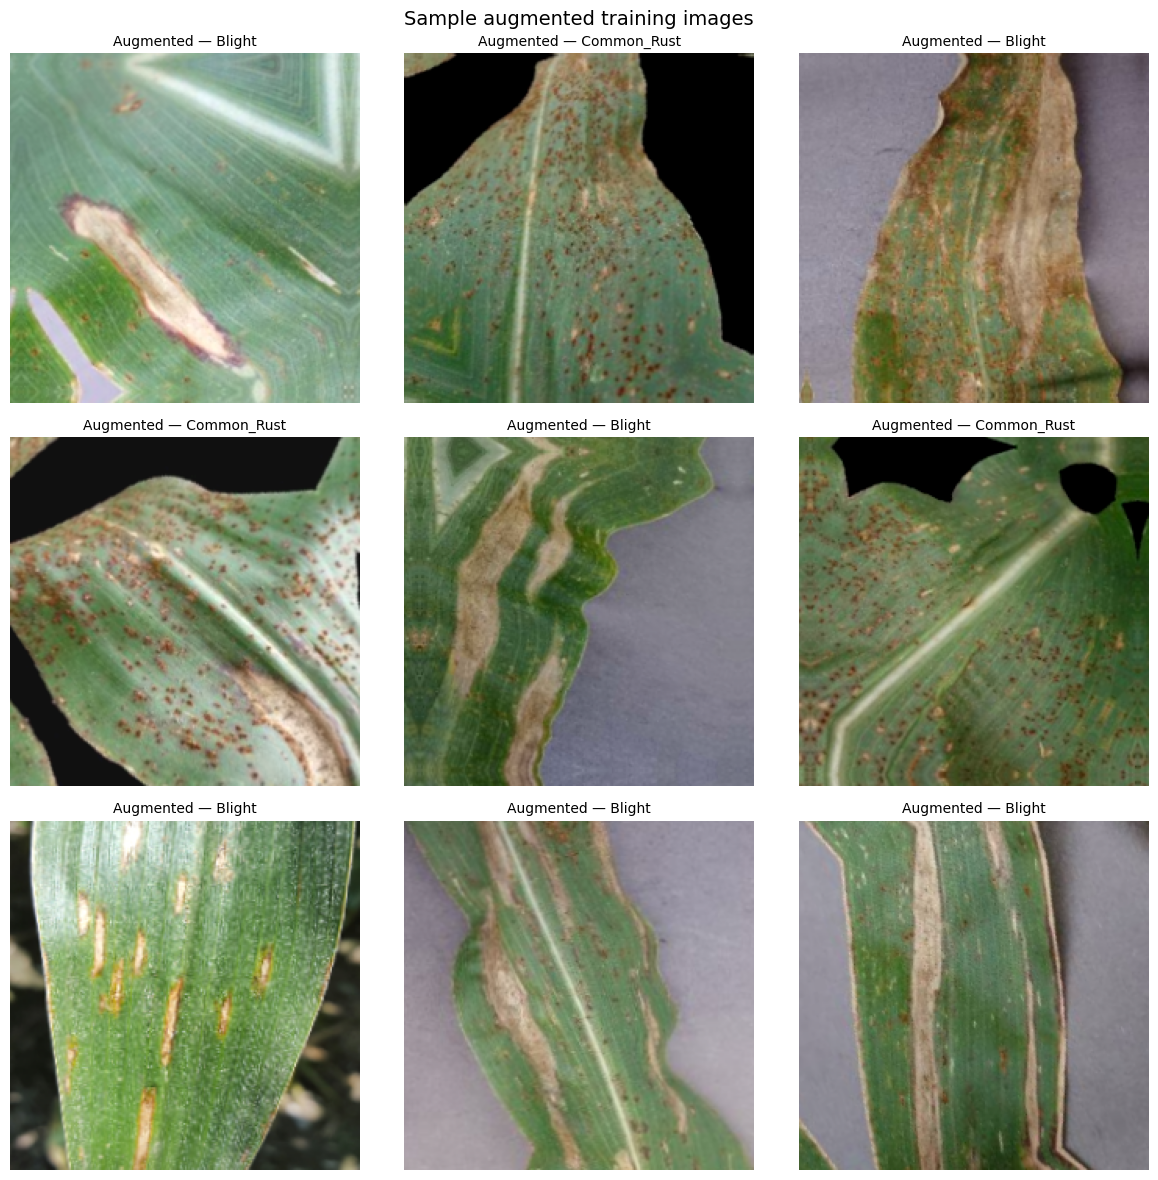

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1, value_range=(0, 255)),
], name="data_augmentation")

# Preview a few augmented images
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented = data_augmentation(tf.expand_dims(images[i % len(images)], 0))
        plt.imshow(tf.cast(augmented[0], tf.uint8).numpy())
        true_class = CONFIG["class_names"][np.argmax(labels[i % len(labels)].numpy())]
        plt.title(f"Augmented — {true_class}", fontsize=10)
        plt.axis("off")
plt.suptitle("Sample augmented training images", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Build the model — MobileNetV2 + classification head

Three layers:

1. **Input pipeline** — augmentation, then ImageNet-style preprocessing.
2. **Backbone** — MobileNetV2 pre-trained on ImageNet, top classification layer removed.
3. **Classification head** — global average pooling → dense → dropout → 4-class softmax.

### Why this architecture

MobileNetV2's depthwise separable convolutions reduce parameters by an order of magnitude versus VGG16 or ResNet50, with negligible loss of accuracy. After quantisation, the final TFLite file is roughly 5 MB.

In [9]:
def build_model(num_classes, input_shape=(224, 224, 3)):
    """Construct the MobileNetV2-based classifier."""
    base_model = applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(CONFIG["dense_units"], activation="relu")(x)
    x = layers.Dropout(CONFIG["dropout_rate"])(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="MaizAI_MobileNetV2")
    return model, base_model

model, base_model = build_model(CONFIG["num_classes"])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MaizAI_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Phase 1 — train the classification head

Backbone frozen; only the new head trains. Roughly 1 minute per epoch on T4.

### What to expect

- Training accuracy climbs quickly to 85–95% by epoch 3–4.
- Validation accuracy follows closely, usually within 2–3 points of training accuracy.
- A widening train/val gap would indicate overfitting.

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG["phase1_learning_rate"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Starting Phase 1: training the classification head only")
print(f"Frozen backbone parameters will not be updated.\n")

phase1_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["phase1_epochs"],
    verbose=1,
)

Starting Phase 1: training the classification head only
Frozen backbone parameters will not be updated.

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 226ms/step - accuracy: 0.8413 - loss: 0.4338 - val_accuracy: 0.8964 - val_loss: 0.2434
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9104 - loss: 0.2221 - val_accuracy: 0.9079 - val_loss: 0.2309
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9172 - loss: 0.2033 - val_accuracy: 0.8997 - val_loss: 0.2493
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9303 - loss: 0.1815 - val_accuracy: 0.9178 - val_loss: 0.2295
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9361 - loss: 0.1591 - val_accuracy: 0.9342 - val_loss: 0.2037
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9348 - loss: 0.1538 - val_accuracy: 0.9211 - val_loss: 0.2035
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9478 - loss: 0.1416 - val_accuracy: 0.9194 - val_loss: 0.2297
Epoc

## 8. Phase 2 — fine-tune the top backbone layers

Unfreeze the top ~30% of MobileNetV2 layers and continue at a much lower learning rate.

### Why a 100× smaller learning rate

A high rate during fine-tuning causes "catastrophic forgetting": ImageNet features get overwritten. 1e-5 makes only tiny adjustments per step, preserving prior knowledge.

In [11]:
base_model.trainable = True

for layer in base_model.layers[:CONFIG["phase2_unfreeze_from_layer"]]:
    layer.trainable = False

total_layers = len(base_model.layers)
trainable_layers = sum(layer.trainable for layer in base_model.layers)
print(f"Backbone has {total_layers} layers total")
print(f"  Frozen layers:    {total_layers - trainable_layers}")
print(f"  Trainable layers: {trainable_layers}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG["phase2_learning_rate"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("\nStarting Phase 2: fine-tuning the top backbone layers")
print(f"Learning rate dropped to {CONFIG['phase2_learning_rate']:.0e} (100x lower than Phase 1)\n")

phase2_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["phase1_epochs"] + CONFIG["phase2_epochs"],
    initial_epoch=CONFIG["phase1_epochs"],
    verbose=1,
)

Backbone has 154 layers total
  Frozen layers:    100
  Trainable layers: 54

Starting Phase 2: fine-tuning the top backbone layers
Learning rate dropped to 1e-05 (100x lower than Phase 1)

Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - accuracy: 0.8468 - loss: 0.3833 - val_accuracy: 0.8964 - val_loss: 0.3130
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9097 - loss: 0.2303 - val_accuracy: 0.8898 - val_loss: 0.3336
Epoch 13/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9248 - loss: 0.1999 - val_accuracy: 0.8898 - val_loss: 0.3357
Epoch 14/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9299 - loss: 0.1793 - val_accuracy: 0.8947 - val_loss: 0.3277
Epoch 15/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9385 - loss: 0.1622 - val_accuracy: 0.8964 - val_loss: 0.3227
Epoch 16/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9375 - loss: 0.1599 - val_accuracy: 0.8997 - val_loss: 0.2938
Epoch 17/20
91/91 ━━━━━━━━━━━━━━━━━━

## 9. Plot training and validation curves

Both phases on a single axis with a vertical line marking the transition.

### What to look for

- A small bump at the Phase 1 → Phase 2 boundary is expected.
- Curves staying close together = good generalisation.
- A widening gap = overfitting.

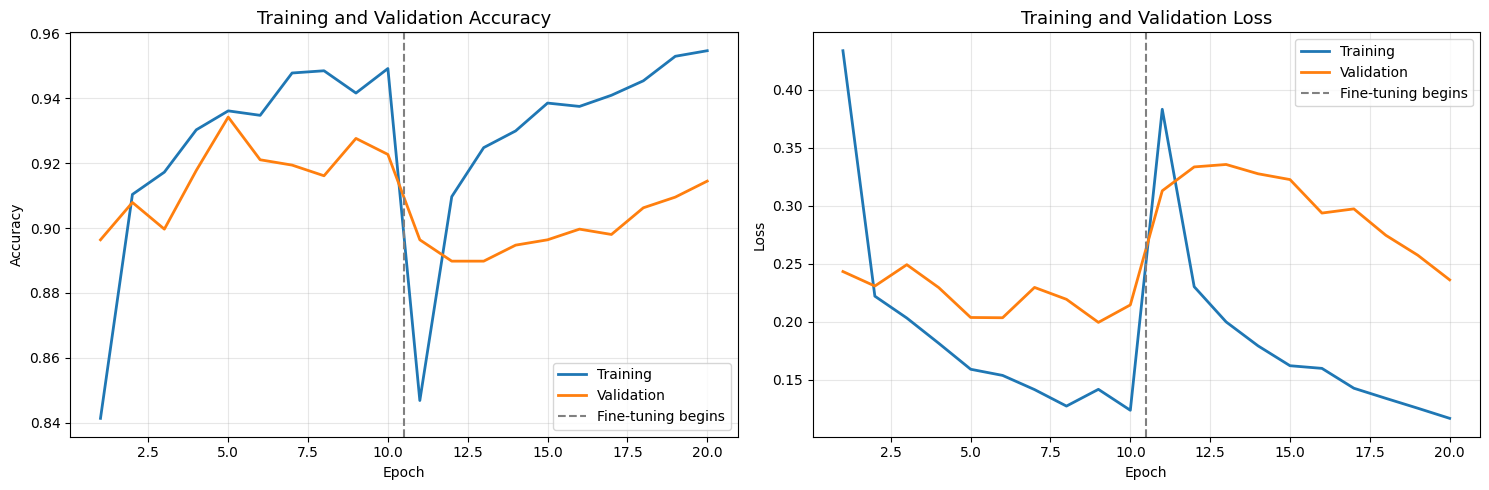

Saved: ./models/training_curves.png


In [12]:
acc = phase1_history.history["accuracy"] + phase2_history.history["accuracy"]
val_acc = phase1_history.history["val_accuracy"] + phase2_history.history["val_accuracy"]
loss = phase1_history.history["loss"] + phase2_history.history["loss"]
val_loss = phase1_history.history["val_loss"] + phase2_history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)
phase_boundary = CONFIG["phase1_epochs"] + 0.5

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(epochs_range, acc, label="Training", linewidth=2)
axes[0].plot(epochs_range, val_acc, label="Validation", linewidth=2)
axes[0].axvline(x=phase_boundary, color="gray", linestyle="--", label="Fine-tuning begins")
axes[0].legend(loc="lower right")
axes[0].set_title("Training and Validation Accuracy", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, loss, label="Training", linewidth=2)
axes[1].plot(epochs_range, val_loss, label="Validation", linewidth=2)
axes[1].axvline(x=phase_boundary, color="gray", linestyle="--", label="Fine-tuning begins")
axes[1].legend(loc="upper right")
axes[1].set_title("Training and Validation Loss", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {CONFIG['output_dir']}/training_curves.png")

## 10. Evaluate on the held-out test set

The test set was set aside before training. Performance on it is our estimate of how the model will perform on new images.

### What gets reported

- **Overall accuracy** — the headline number.
- **Per-class precision** — of the leaves the model called "Common Rust", how many were actually rust?
- **Per-class recall** — of the leaves that actually had rust, how many did the model catch?
- **F1 score** — harmonic mean of precision and recall.
- **Confusion matrix** — which classes get confused with which.

In [13]:
y_true = []
y_pred = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
    y_pred_probs.extend(np.max(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CONFIG["class_names"], digits=4))

report_dict = classification_report(
    y_true, y_pred,
    target_names=CONFIG["class_names"],
    output_dict=True,
)
report_dict["mean_prediction_confidence"] = float(np.mean(y_pred_probs))
report_dict["test_set_size"] = int(len(y_true))

with open(f"{CONFIG['output_dir']}/metrics.json", "w") as f:
    json.dump(report_dict, f, indent=2)

print(f"\nSaved: {CONFIG['output_dir']}/metrics.json")
print(f"Test-set size: {len(y_true)} images")
print(f"Mean prediction confidence: {np.mean(y_pred_probs):.4f}")

CLASSIFICATION REPORT
                precision    recall  f1-score   support

   Common_Rust     0.9409    0.9904    0.9650       209
Gray_Leaf_Spot     0.8625    0.8023    0.8313        86
       Healthy     0.9845    1.0000    0.9922       190
        Blight     0.9600    0.9180    0.9385       183

      accuracy                         0.9491       668
     macro avg     0.9370    0.9277    0.9318       668
  weighted avg     0.9484    0.9491    0.9483       668


Saved: ./models/metrics.json
Test-set size: 668 images
Mean prediction confidence: 0.9643


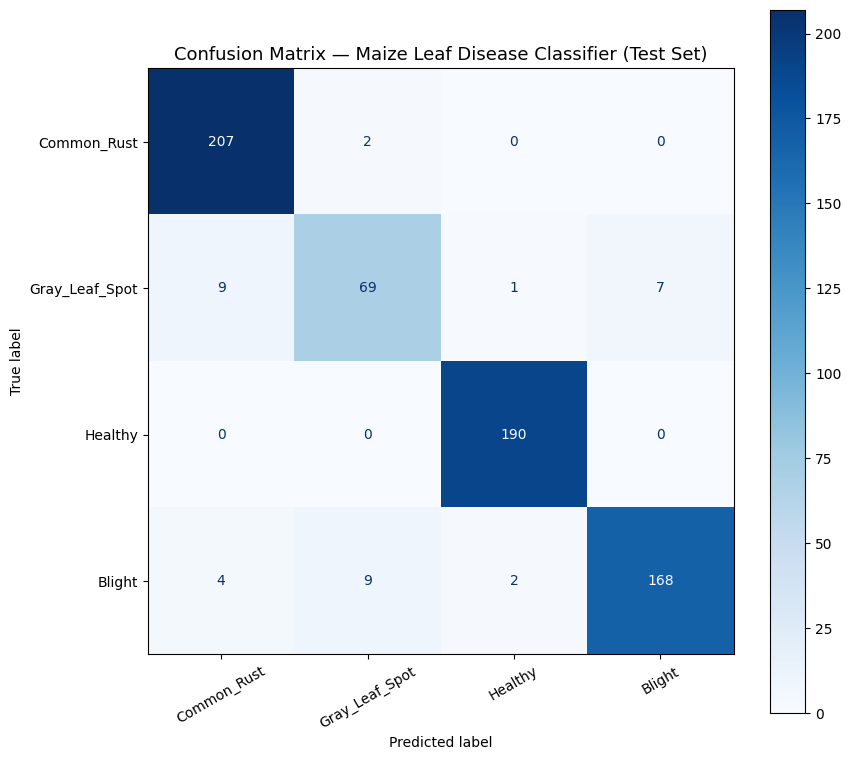


Saved: ./models/confusion_matrix.png


In [14]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CONFIG["class_names"],
)

fig, ax = plt.subplots(figsize=(9, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30, values_format="d")
plt.title("Confusion Matrix — Maize Leaf Disease Classifier (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved: {CONFIG['output_dir']}/confusion_matrix.png")

## 11. Convert the trained model to TensorFlow Lite

Post-training integer quantisation. This is the artifact that ships in the mobile application.

### What quantisation does

| Property | Before | After |
|---|---|---|
| Model size | ~14 MB | ~3.5 MB |
| Inference time on phone | ~150 ms | ~50 ms |
| Accuracy | (baseline) | typically within 0.5–1.0% |

In [15]:
model.save(f"{CONFIG['output_dir']}/maize_classifier_full.keras")
print(f"Full Keras model saved: {CONFIG['output_dir']}/maize_classifier_full.keras")

def representative_dataset_gen():
    count = 0
    for images, _ in train_ds:
        for image in images:
            if count >= 100:
                return
            image = tf.cast(tf.expand_dims(image, axis=0), tf.float32)
            yield [image]
            count += 1

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

print("Converting to TensorFlow Lite (this takes 1–2 minutes)...")
tflite_model = converter.convert()

TFLITE_PATH = f"{CONFIG['output_dir']}/maize_classifier.tflite"
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
print(f"\nTFLite model saved: {TFLITE_PATH}")
print(f"Model size: {size_mb:.2f} MB")

Full Keras model saved: ./models/maize_classifier_full.keras
Converting to TensorFlow Lite (this takes 1–2 minutes)...
Saved artifact at '/tmp/tmp2t13j3r1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_160')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133383041867920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133383031178832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133383031179024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133383031178256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133383031177680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133383031178640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133383031180560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133383031180368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133383031179984: TensorSpec(sha

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



TFLite model saved: ./models/maize_classifier.tflite
Model size: 2.74 MB


## 12. Sanity-check the TFLite model

Load the `.tflite` back with the TFLite interpreter and verify it produces sensible predictions on test images. If predictions diverge from the Keras model, something went wrong during quantisation.

In [16]:
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:")
print(f"  Name:   {input_details[0]['name']}")
print(f"  Shape:  {input_details[0]['shape']}")
print(f"  Dtype:  {input_details[0]['dtype']}")
print(f"\nOutput details:")
print(f"  Name:   {output_details[0]['name']}")
print(f"  Shape:  {output_details[0]['shape']}")
print(f"  Dtype:  {output_details[0]['dtype']}")

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS (TFLite model)")
print("=" * 60)
correct = 0
total = 0
for images, labels in test_ds.take(2):
    for i in range(min(6, len(images))):
        img = tf.cast(images[i], tf.uint8).numpy()
        true_idx = np.argmax(labels[i].numpy())
        interpreter.set_tensor(input_details[0]["index"], np.expand_dims(img, axis=0))
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]["index"])
        pred_idx = np.argmax(output)
        marker = "✓" if pred_idx == true_idx else "✗"
        true_name = CONFIG["class_names"][true_idx]
        pred_name = CONFIG["class_names"][pred_idx]
        print(f"  {marker}  True: {true_name:25s}  Predicted: {pred_name}")
        correct += int(pred_idx == true_idx)
        total += 1

print(f"\nSanity check: {correct}/{total} correct")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input details:
  Name:   serving_default_keras_tensor_160:0
  Shape:  [  1 224 224   3]
  Dtype:  <class 'numpy.uint8'>

Output details:
  Name:   StatefulPartitionedCall_1:0
  Shape:  [1 4]
  Dtype:  <class 'numpy.uint8'>

SAMPLE PREDICTIONS (TFLite model)
  ✓  True: Common_Rust                Predicted: Common_Rust
  ✓  True: Healthy                    Predicted: Healthy
  ✓  True: Healthy                    Predicted: Healthy
  ✓  True: Blight                     Predicted: Blight
  ✓  True: Common_Rust                Predicted: Common_Rust
  ✓  True: Healthy                    Predicted: Healthy
  ✓  True: Common_Rust                Predicted: Common_Rust
  ✗  True: Blight                     Predicted: Gray_Leaf_Spot
  ✓  True: Blight                     Predicted: Blight
  ✓  True: Common_Rust                Predicted: Common_Rust
  ✓  True: Blight                     Predicted: Blight
  ✓  True: Healthy                    Predicted: Healthy

Sanity check: 11/12 correct


## 13. Download the artifacts

Downloads four files for the repository:

| File | Purpose |
|---|---|
| `maize_classifier.tflite` | The trained model, embedded in the mobile app |
| `metrics.json` | Test-set metrics for Chapter 4 |
| `training_curves.png` | Training visualisation for Chapter 4 |
| `confusion_matrix.png` | Confusion matrix for Chapter 4 |

Place these in `maizai/ai/models/`, then commit and push.

In [18]:
from google.colab import files

print("Downloading artifacts...")
files.download(f"{CONFIG['output_dir']}/maize_classifier.tflite")
files.download(f"{CONFIG['output_dir']}/metrics.json")
files.download(f"{CONFIG['output_dir']}/training_curves.png")
files.download(f"{CONFIG['output_dir']}/confusion_matrix.png")
print("\nAll four artifacts downloaded.")
print("Place them in: maizai/ai/models/")
print("Then commit and push.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All four artifacts downloaded.
Place them in: maizai/ai/models/
Then commit and push.
